In [1]:
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rasterio.windows import Window
from rasterio.transform import rowcol
import pickle

In [2]:
# official Lunar Permanently Shadowed Region (LPSR) product
# ref: Mazarico et al. (2011), Icarus, doi:10.1016/j.icarus.2010.10.030
# accessed via NASA PGDA: https://pgda.gsfc.nasa.gov/products/90

lpsr_path = '../00_raw_data/PSRs/LPSR_80S_20MPP_ADJ.tiff'

with rasterio.open(lpsr_path) as src:
    print(f"CRS:        {src.crs}")
    print(f"Resolution: {src.res} m/px")
    print(f"Bounds:     {src.bounds}")
    print(f"NoData:     {src.nodata}")
    print(f"Data type:  {src.dtypes[0]}")

    check_arr  = src.read(1)
    print(f"Unique values: {np.unique(check_arr)[:10]}")
    px_size_lpsr = src.res[0]

CRS:        PROJCS["Moon (2015) - Sphere / Ocentric / South Polar",GEOGCS["Moon (2015) - Sphere / Ocentric",DATUM["Moon (2015) - Sphere",SPHEROID["Moon (2015) - Sphere",1737400,0,AUTHORITY["IAU","30100"]],AUTHORITY["IAU","30100"]],PRIMEM["Reference Meridian",0,AUTHORITY["IAU","30100"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["IAU","30100"]],PROJECTION["Polar_Stereographic"],PARAMETER["latitude_of_origin",-90],PARAMETER["central_meridian",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",NORTH],AXIS["Northing",NORTH],AUTHORITY["IAU","30135"]]
Resolution: (20.0, 20.0) m/px
Bounds:     BoundingBox(left=-304000.0, bottom=-304000.0, right=304000.0, top=304000.0)
NoData:     nan
Data type:  float32


C:\Users\Aska\AppData\Local\Temp\ipykernel_31576\1620161909.py:14: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  check_arr  = src.read(1)


Unique values: [0. 1.]


In [3]:
# CRITICAL: the transform saved here is corrected for the cropped window,
# not the full raster -- this is required for correct pixel-to-coordinate
# mapping when locating PSR pixels relative to candidate EZ centers in
# notebook 06

sites_df = pd.read_csv('../01_cleaned_data/sites_df.csv')
px_size_slope = 40

with rasterio.open(lpsr_path) as src:
    for _, row in sites_df.iterrows():
        site_key  = row['site_key']
        grid_file = f'../01_cleaned_data/site_grids/{site_key}_grids.pkl'

        with open(grid_file, 'rb') as f:
            g = pickle.load(f)

        search_ws_lpsr    = int(g['search_ws'] * (px_size_slope / px_size_lpsr))
        ez_radius_px_lpsr = int(2000 / px_size_lpsr)
        buf_lpsr          = ez_radius_px_lpsr

        py, px_c = rowcol(src.transform, row['X_stereo'], row['Y_stereo'])

        r0 = max(0, py   - search_ws_lpsr - buf_lpsr)
        r1 = min(src.height, py + search_ws_lpsr + buf_lpsr)
        c0 = max(0, px_c - search_ws_lpsr - buf_lpsr)
        c1 = min(src.width,  px_c + search_ws_lpsr + buf_lpsr)

        win = Window(c0, r0, c1-c0, r1-r0)
        arr = src.read(1, window=win)

        if src.nodata is not None:
            arr = np.where(arr == src.nodata, np.nan, arr).astype(float)
        else:
            arr = arr.astype(float)

        is_psr = (arr >= 0.5).astype(float)

        window_transform = rasterio.windows.transform(win, src.transform)

        g['lpsr_grid']      = is_psr
        g['lpsr_transform'] = window_transform
        g['px_size_lpsr']   = px_size_lpsr

        with open(grid_file, 'wb') as f:
            pickle.dump(g, f)

        psr_pct = round(float(np.nanmean(is_psr)) * 100, 2)
        print(f"{row['Site']:25s}  LPSR grid: {is_psr.shape}  "
              f"PSR coverage: {psr_pct}%  "
              f"transform origin: ({window_transform.c:.0f}, {window_transform.f:.0f})")

print("\nLPSR grids saved.")

C:\Users\Aska\AppData\Local\Temp\ipykernel_31576\2139910783.py:29: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  arr = src.read(1, window=win)


Nobile Rim 2               LPSR grid: (1204, 1204)  PSR coverage: 13.23%  transform origin: (145180, 107180)
Mons Mouton                LPSR grid: (1004, 1004)  PSR coverage: 2.88%  transform origin: (63060, 128240)
Malapert Massif            LPSR grid: (1252, 1252)  PSR coverage: 1.2%  transform origin: (-13040, 134480)
de Gerlache Rim 2          LPSR grid: (1200, 1200)  PSR coverage: 2.5%  transform origin: (-61380, 35360)
Mons Mouton Plateau        LPSR grid: (4036, 4036)  PSR coverage: 2.49%  transform origin: (47440, 192560)
Slater Plain               LPSR grid: (1200, 1200)  PSR coverage: 5.91%  transform origin: (58460, -38320)
Peak near Cabeus B         LPSR grid: (1200, 1200)  PSR coverage: 0.48%  transform origin: (-192260, 82100)
Nobile Rim 1               LPSR grid: (1200, 1200)  PSR coverage: 2.04%  transform origin: (72200, 122360)
Haworth                    LPSR grid: (1692, 1692)  PSR coverage: 1.98%  transform origin: (-55320, 108500)

LPSR grids saved.


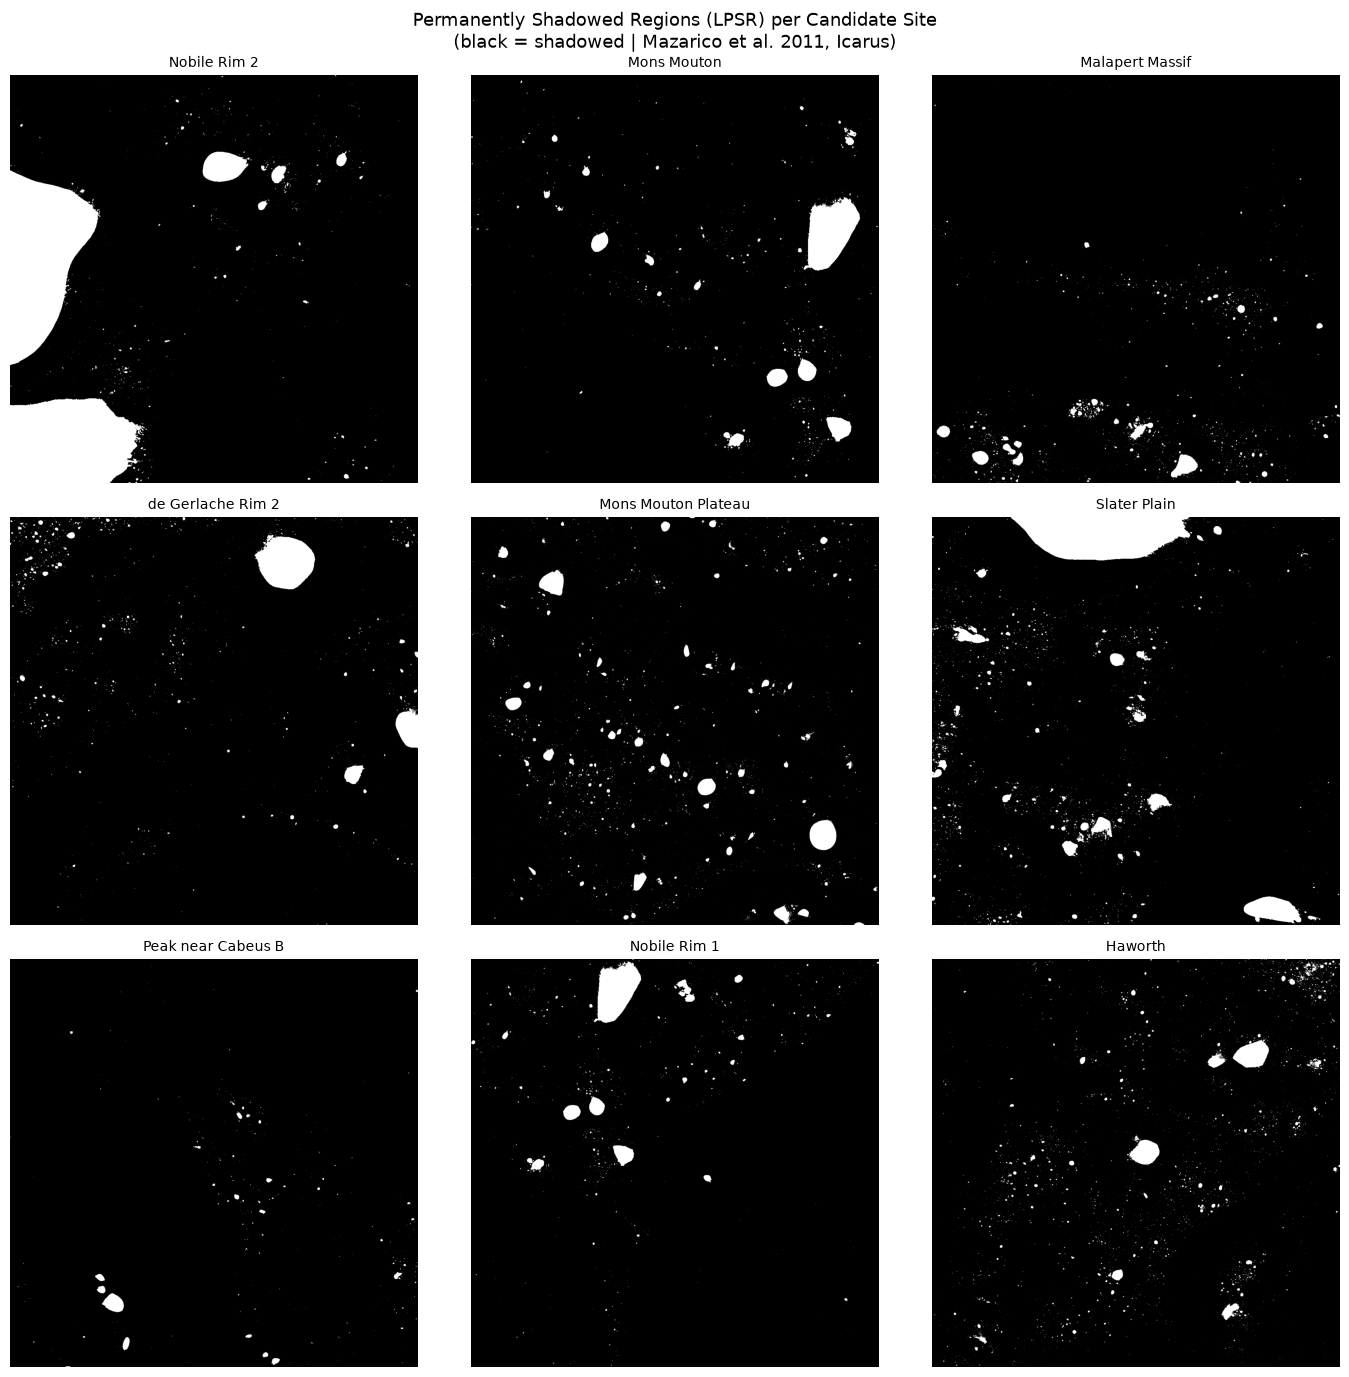

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(14, 14))

for ax, (_, row) in zip(axes.flat, sites_df.iterrows()):
    site_key  = row['site_key']
    grid_file = f'../01_cleaned_data/site_grids/{site_key}_grids.pkl'
    with open(grid_file, 'rb') as f:
        g = pickle.load(f)

    ax.imshow(g['lpsr_grid'], cmap='Greys_r', vmin=0, vmax=1)
    ax.set_title(row['Site'], fontsize=10)
    ax.axis('off')

plt.suptitle('Permanently Shadowed Regions (LPSR) per Candidate Site\n'
             '(black = shadowed | Mazarico et al. 2011, Icarus)', fontsize=13)
plt.tight_layout()
plt.show()